# Experiment Analysis
Analyze results from the experiment pipeline. Compare performance across reflection levels and threat domains.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation.visualizations import (
    plot_comparison, plot_confusion_matrix, plot_roc_curve,
    plot_cost_vs_performance, plot_domain_comparison
)
from src.evaluation.metrics import compare_levels, mcnemar_test

sns.set_theme(style='whitegrid')

In [2]:
# Load latest experiment results
results_dir = '../experiments/results/'
result_files = sorted(glob.glob(os.path.join(results_dir, 'experiment_*.json')))

if not result_files:
    print('No experiment results found. Run the experiment first:')
    print('  python -m experiments.run_experiment --samples 10')
else:
    latest = result_files[-1]
    print(f'Loading: {latest}')
    with open(latest) as f:
        data = json.load(f)
    print(f'Timestamp: {data["timestamp"]}')
    print(f'Domains: {data["config"]["domains"]}')
    print(f'Levels: {data["config"]["levels"]}')

Loading: ../experiments/results\experiment_20260404_153425.json
Timestamp: 20260404_153425
Domains: ['phishing']
Levels: [0, 1, 2]



=== PHISHING ===
       accuracy  precision  recall  f1_score  false_positive_rate  false_negative_rate  roc_auc
level                                                                                          
0           0.9   0.833333     1.0  0.909091                  0.2                  0.0      1.0
1           1.0   1.000000     1.0  1.000000                  0.0                  0.0      1.0
2           1.0   1.000000     1.0  1.000000                  0.0                  0.0      1.0


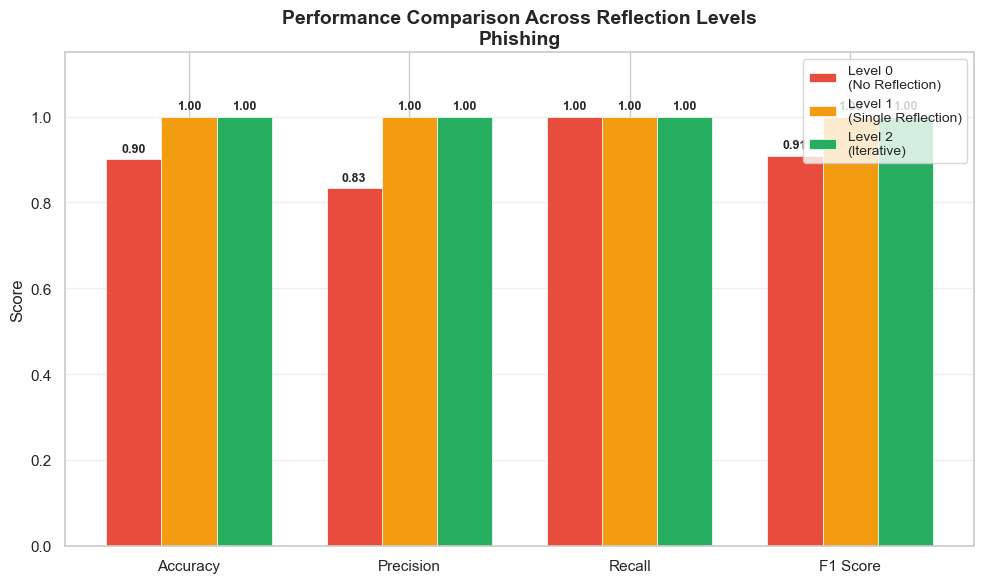

In [3]:
# Performance comparison table
if result_files:
    for domain in data['results']:
        print(f'\n=== {domain.upper()} ===')
        metrics_by_level = {}
        for level_str, result in data['results'][domain].items():
            metrics_by_level[int(level_str)] = result['metrics']
        
        comparison = compare_levels(metrics_by_level)
        print(comparison.to_string())
        
        # Plot comparison
        fig = plot_comparison(metrics_by_level, domain=domain.replace('_', ' ').title())
        plt.show()

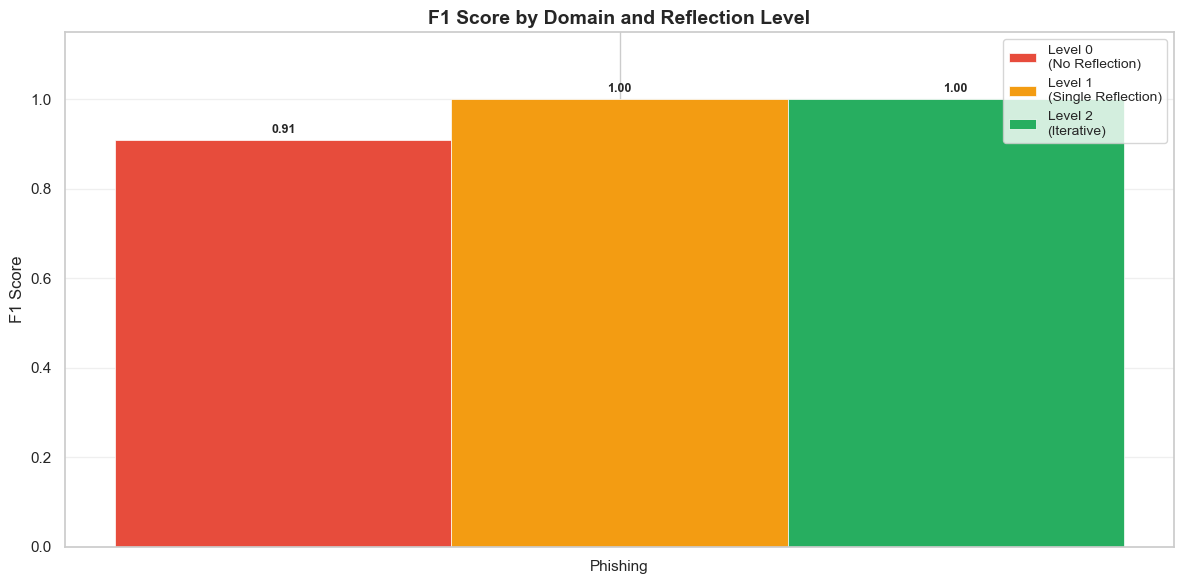

In [4]:
# Cross-domain F1 comparison
if result_files:
    domain_metrics = {}
    for domain in data['results']:
        domain_metrics[domain] = {}
        for level_str, result in data['results'][domain].items():
            domain_metrics[domain][int(level_str)] = result['metrics']
    
    fig = plot_domain_comparison(domain_metrics)
    plt.show()

In [5]:
# Statistical significance
if result_files and 'significance_tests' in data:
    print('McNemar\'s Test Results (Level 0 vs Level 2):')
    print('=' * 50)
    for domain, test in data['significance_tests'].items():
        sig = 'SIGNIFICANT' if test['significant'] else 'NOT significant'
        print(f'{domain}: p={test["p_value"]:.4f} - {sig}')

McNemar's Test Results (Level 0 vs Level 2):
phishing: p=1.0000 - SIGNIFICANT


Cost Summary by Level:
       total_tokens  api_calls  wall_time_seconds
level                                            
0               0.0        1.0           9.575889
1               0.0        2.1          21.957927
2               0.0        2.2          21.952335


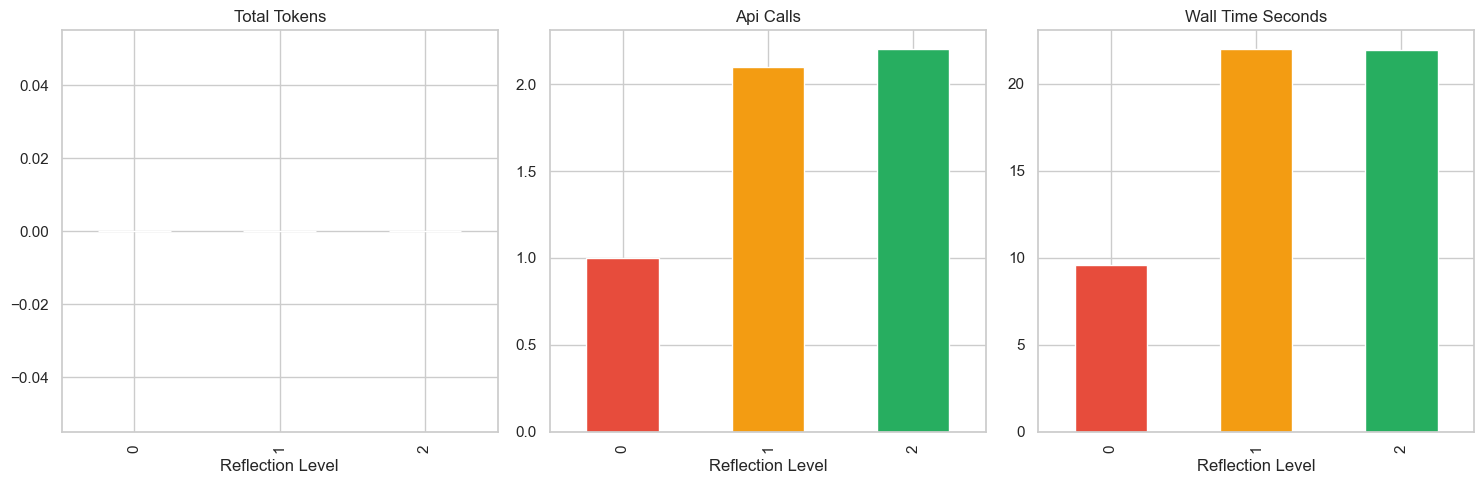

In [6]:
# Cost analysis
if result_files:
    cost_files = sorted(glob.glob(os.path.join(results_dir, 'costs_*.csv')))
    if cost_files:
        cost_df = pd.read_csv(cost_files[-1])
        print('Cost Summary by Level:')
        print(cost_df.groupby('level')[['total_tokens', 'api_calls', 'wall_time_seconds']].mean())
        
        # Plot cost vs level
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for ax, metric in zip(axes, ['total_tokens', 'api_calls', 'wall_time_seconds']):
            cost_df.groupby('level')[metric].mean().plot(kind='bar', ax=ax,
                color=['#e74c3c', '#f39c12', '#27ae60'])
            ax.set_title(metric.replace('_', ' ').title())
            ax.set_xlabel('Reflection Level')
        plt.tight_layout()
        plt.show()